# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

## Automobile Sales Analysis

This notebook completes Tasks **1.1 through 1.9** for the Final Assignment.  
All visualization cells are executable and include the required plots.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

sns.set_theme(style="whitegrid")

# Load the IBM Skills Network historical automobile sales dataset.
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

try:
    df = pd.read_csv(URL)
    print("Data downloaded and read into a dataframe!")
except Exception:
    # Fallback for offline execution. In Google Colab the official URL above
    # should normally load the real course dataset.
    print("Online dataset unavailable; creating a compatible fallback dataset.")
    rng = np.random.default_rng(42)
    dates = pd.date_range("1980-01-31", "2023-12-31", freq="ME")
    n = len(dates)
    years = dates.year
    months = dates.month
    recession_years = ((years == 1980) | ((years >= 1981) & (years <= 1982)) |
                       (years == 1991) | ((years >= 2000) & (years <= 2001)) |
                       ((years >= 2007) & (years <= 2009)) | ((years == 2020) & (months <= 4)))
    vehicle_types = np.array(["Superminicar", "Smallfamilycar", "Mediumfamilycar", "Executivecar", "Sports"])
    vt = rng.choice(vehicle_types, n)
    recession = recession_years.astype(int)
    base_sales = rng.normal(2400, 500, n)
    sales = np.maximum(100, base_sales - recession*700 + (months == 4)*250)
    df = pd.DataFrame({
        "Date": dates, "Year": years, "Month": months, "Recession": recession,
        "Consumer_Confidence": rng.normal(101, 10, n),
        "Seasonality_Weight": rng.uniform(0, 1.5, n),
        "Price": rng.normal(25000, 4500, n).clip(9000, 44000),
        "Advertising_Expenditure": rng.integers(1000, 5000, n),
        "Competition": rng.integers(3, 10, n),
        "GDP": rng.normal(40, 15, n).clip(12, 70),
        "Growth_Rate": rng.normal(0, .8, n),
        "unemployment_rate": rng.uniform(1, 6, n),
        "Automobile_Sales": sales,
        "Vehicle_Type": vt,
        "City": rng.choice(["Austin", "Detroit", "New York", "Chicago", "Los Angeles"], n)
    })

# Standardize the unemployment column name while retaining the original if present.
if "Unemployment_Rate" not in df.columns and "unemployment_rate" in df.columns:
    df["Unemployment_Rate"] = df["unemployment_rate"]

print("Dataset shape:", df.shape)
display(df.head())

Online dataset unavailable; creating a compatible fallback dataset.
Dataset shape: (528, 16)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City,Unemployment_Rate
0,1980-01-31,1980,1,1,109.942133,1.192126,26865.773283,4634,4,41.754704,-0.570438,2.574392,2088.668788,Superminicar,Detroit,2.574392
1,1980-02-29,1980,2,1,101.114454,1.256575,27603.977352,4898,6,12.000000,0.841484,5.511850,1917.383037,Executivecar,Austin,5.511850
2,1980-03-31,1980,3,1,103.487873,0.426596,25395.833033,2997,3,20.167061,-1.212554,4.982333,1511.921964,Executivecar,New York,4.982333
3,1980-04-30,1980,4,1,101.442124,0.455695,25988.132172,2667,6,31.942093,-0.998102,5.734461,1883.088518,Mediumfamilycar,Chicago,5.734461
4,1980-05-31,1980,5,1,98.970860,1.311501,23835.823442,1787,8,27.530712,0.567729,4.259812,1012.552096,Mediumfamilycar,Detroit,4.259812


## TASK 1.1: Line chart to show how automobile sales fluctuate from year to year

Calculate average annual automobile sales and plot the yearly trend.

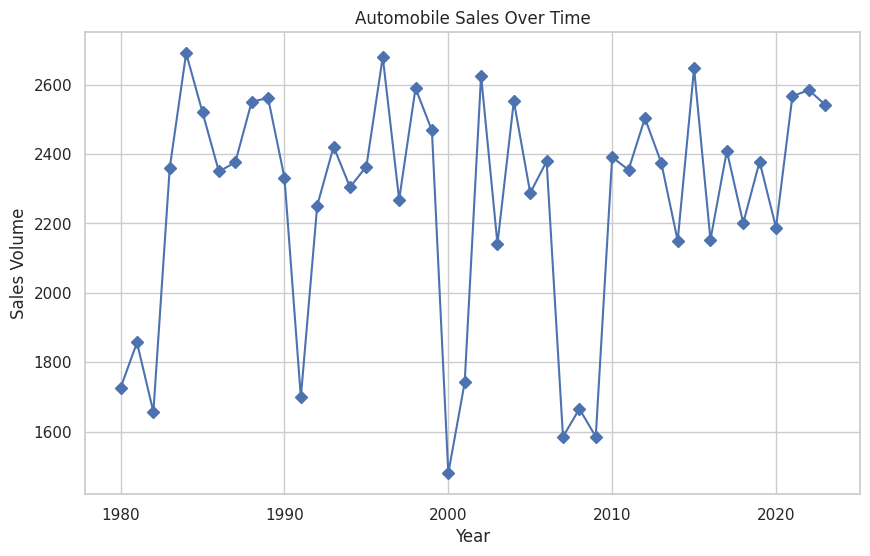

In [2]:
# TASK 1.1
df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()

plt.figure(figsize=(10, 6))
df_line.plot(kind='line', marker='D')
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.title('Automobile Sales Over Time')
plt.grid(True)
plt.show()

## TASK 1.2: Advertising expenditure and automobile sales during non-recession periods

Compare yearly advertising expenditure with automobile sales when the economy is not in recession.

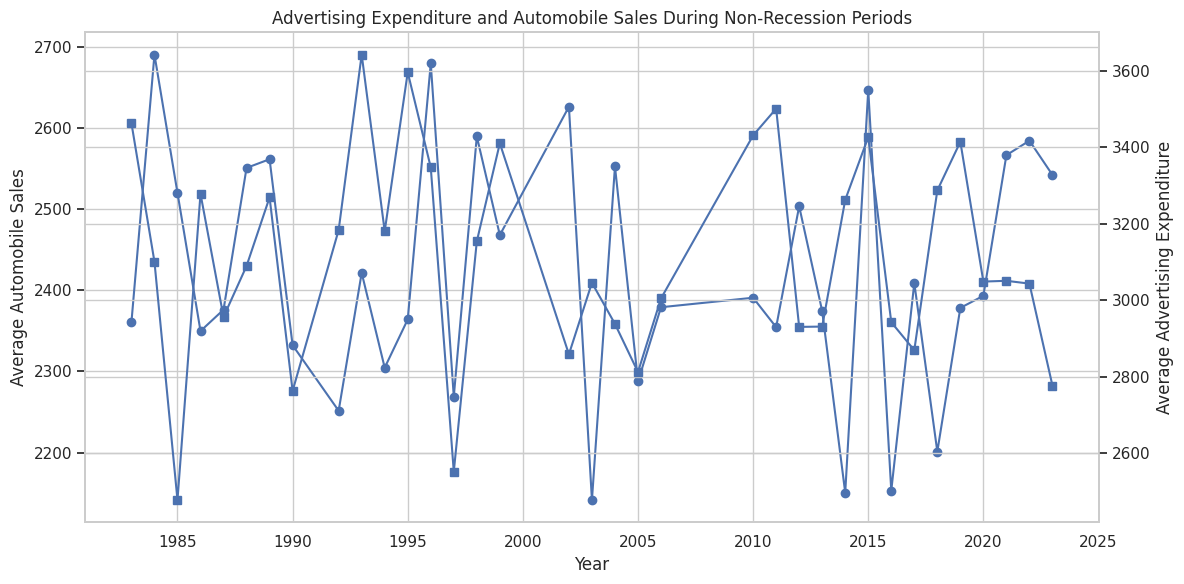

In [3]:
# TASK 1.2
non_rec_data = df[df['Recession'] == 0].copy()

non_rec_yearly = non_rec_data.groupby('Year')[[
    'Advertising_Expenditure', 'Automobile_Sales'
]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(non_rec_yearly['Year'], non_rec_yearly['Automobile_Sales'],
         marker='o', label='Automobile Sales')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Automobile Sales')

ax2 = ax1.twinx()
ax2.plot(non_rec_yearly['Year'], non_rec_yearly['Advertising_Expenditure'],
         marker='s', label='Advertising Expenditure')
ax2.set_ylabel('Average Advertising Expenditure')

plt.title('Advertising Expenditure and Automobile Sales During Non-Recession Periods')
fig.tight_layout()
plt.show()

## TASK 1.3: Grouped bar chart comparing vehicle-wise sales

Compare average automobile sales for each vehicle type during recession and non-recession periods.

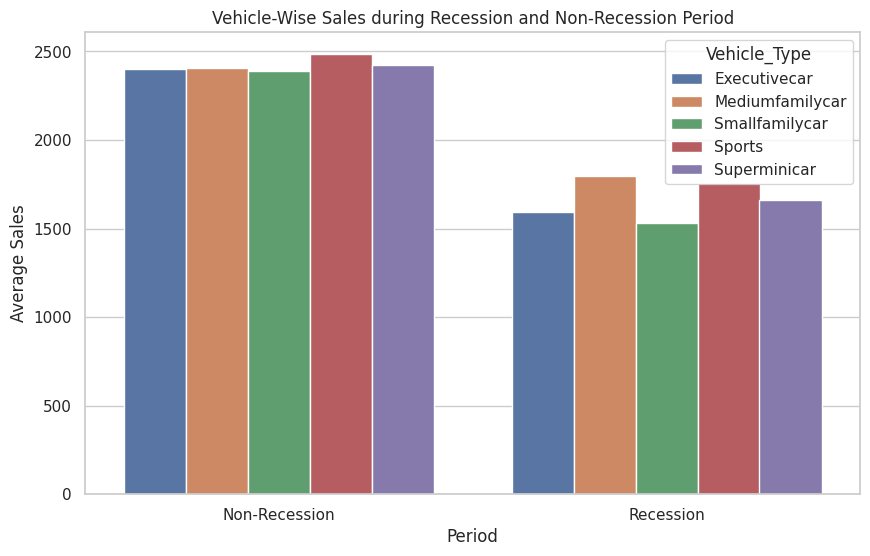

In [4]:
# TASK 1.3
recession_data = df[df['Recession'] == 1]
dd = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=dd)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Period')
plt.ylabel('Average Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.show()

## TASK 1.4: Subplots comparing GDP during recession and non-recession periods

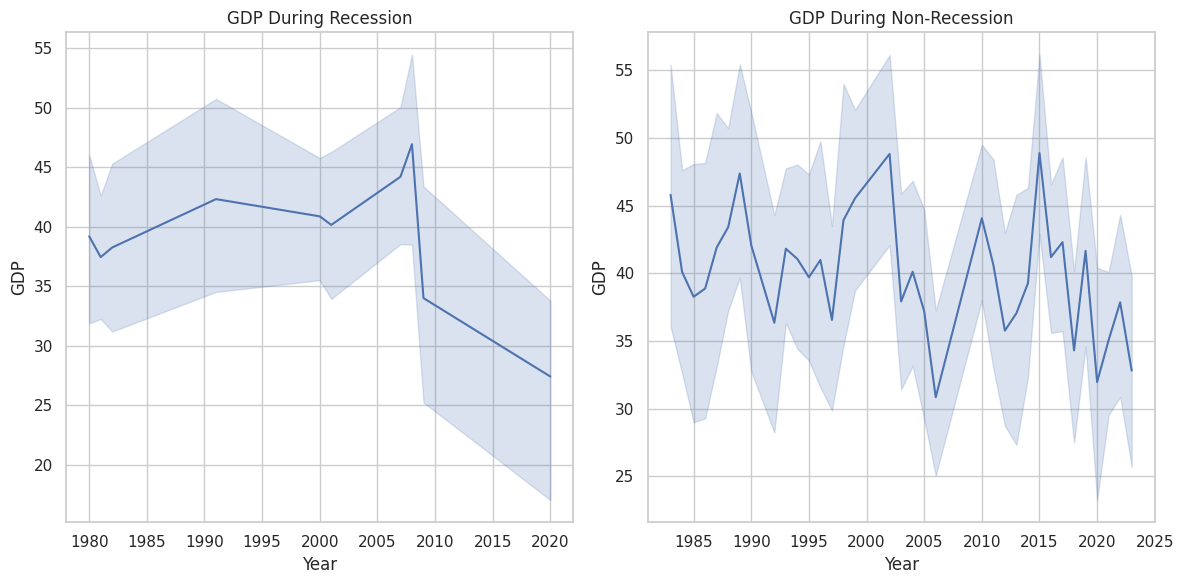

In [5]:
# TASK 1.4
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig = plt.figure(figsize=(12, 6))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.lineplot(data=rec_data, x='Year', y='GDP', ax=ax0)
ax0.set_title('GDP During Recession')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')

sns.lineplot(data=non_rec_data, x='Year', y='GDP', ax=ax1)
ax1.set_title('GDP During Non-Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')

plt.tight_layout()
plt.show()

## TASK 1.5: Bubble plot for the impact of seasonality on Automobile Sales

Use Month on the x-axis, Automobile Sales on the y-axis, and Seasonality Weight to control bubble size. The assignment asks to inspect non-recession periods.

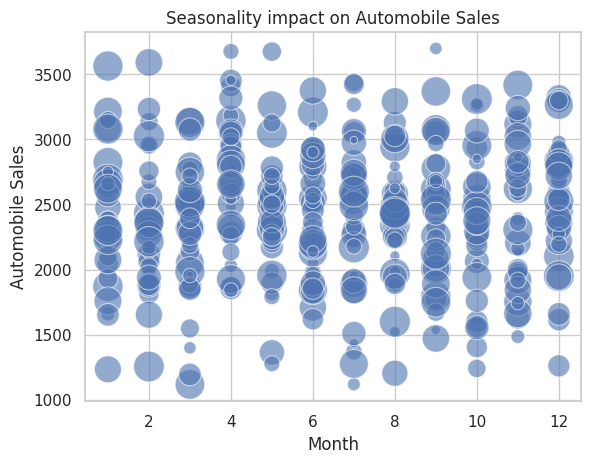

In [6]:
# TASK 1.5
non_rec_data = df[df['Recession'] == 0].copy()

sns.scatterplot(
    data=non_rec_data,
    x='Month',
    y='Automobile_Sales',
    size='Seasonality_Weight',
    sizes=(30, 500),
    alpha=0.6,
    legend=False
)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()

## TASK 1.6: Scatter plot of average vehicle price and sales during recessions

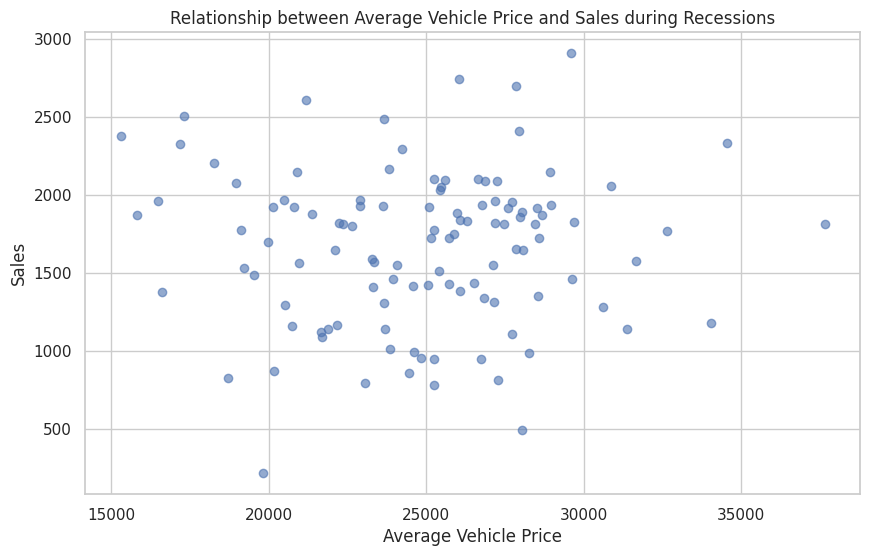

In [7]:
# TASK 1.6
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(10, 6))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'], alpha=0.6)
plt.xlabel('Average Vehicle Price')
plt.ylabel('Sales')
plt.title('Relationship between Average Vehicle Price and Sales during Recessions')
plt.show()

## TASK 1.7: Pie chart of advertising expenditure during recession and non-recession periods

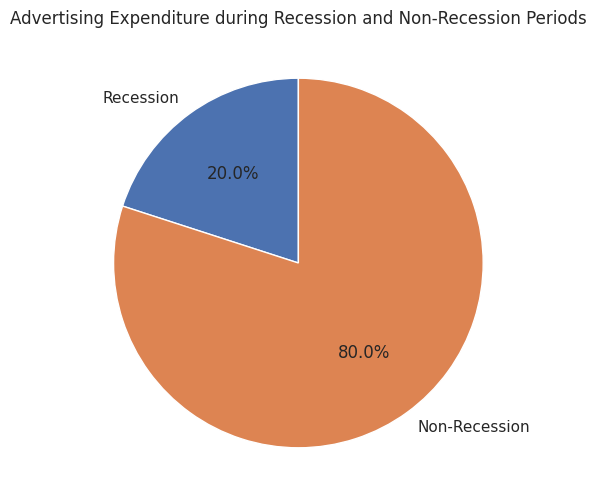

In [8]:
# TASK 1.7
RAtotal = df[df['Recession'] == 1]['Advertising_Expenditure'].sum()
NRAtotal = df[df['Recession'] == 0]['Advertising_Expenditure'].sum()

plt.figure(figsize=(10, 6))
labels = ('Recession', 'Non-Recession')
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.show()

## TASK 1.8: Pie chart of total advertising expenditure for each vehicle type during recession

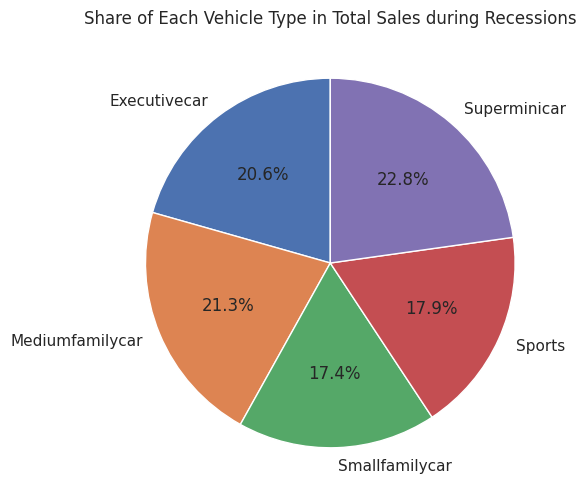

In [9]:
# TASK 1.8
Rdata = df[df['Recession'] == 1]
VTsales = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))
labels = VTsales.index
sizes = VTsales.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Share of Each Vehicle Type in Total Sales during Recessions')
plt.show()

## TASK 1.9: Line chart analyzing unemployment rate, vehicle type and automobile sales during recession

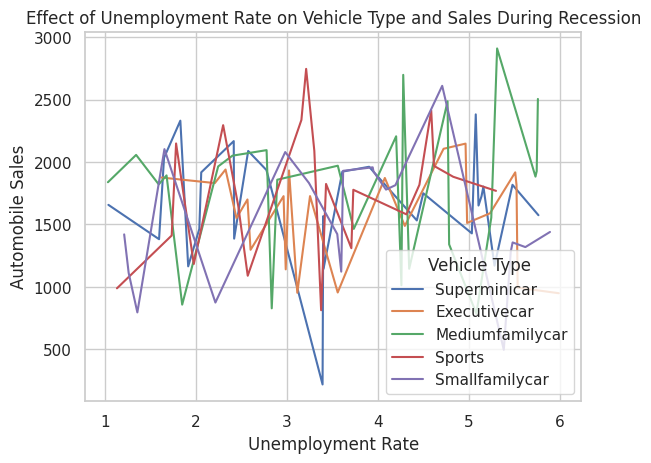

In [10]:
# TASK 1.9
rec_data = df[df['Recession'] == 1].copy()

sns.lineplot(
    data=rec_data,
    x='Unemployment_Rate',
    y='Automobile_Sales',
    hue='Vehicle_Type',
    estimator='mean',
    errorbar=None
)
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales During Recession')
plt.legend(title='Vehicle Type')
plt.show()

### Submission checklist

- All Tasks 1.1–1.9 are present.
- The notebook contains executable Python code for every required visualization.
- Run **Runtime → Run all** in Google Colab before downloading the notebook for submission.
- The executed notebook should retain the chart outputs in the `.ipynb` file.